In [195]:
import numpy as np
import matplotlib.pyplot as plt

global L, J, beta

L = 100
J = 1.
beta = 1.

def N_thermalisation(Nt) : # le systeme a besoin de thermaliser avant que l'on calcul des quantitées
  return int(0.2 * Nt)

In [196]:
def insertion(op_string:np.ndarray, M:int, n:int, p:int, bond:int) ->int:
    if n == M :
        return n
    else :
        prob = (beta * J) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_string[p] = 2 * bond
        n += 1
    return n

def remove(op_string:np.ndarray, M:int, n:int, p:int) ->int:
    prob = (2. *(M - n + 1)) / (beta * J)
    if np.random.rand() <  min(1., prob):
        op_string[p] = -1
        n -= 1
    return n

def diagonal_update(spins:np.ndarray, op_string:np.ndarray, M:int, n:int) -> int: 
    spins_p = spins.copy()
    for p in range(M):
        op = op_string[p]
        if op == -1 : # identity
            bond = np.random.randint(0, L)
            i = bond
            j = (bond + 1) % L

            if spins_p[i] != spins_p[j]: # insertion possible?
                n = insertion(op_string, M, n, p, bond)

        elif op % 2 == 0 : # diagonal
            n = remove(op_string, M, n, p)
        else : # off-diagonal
            b = op_string[p] // 2
            i = b
            j = (b + 1) % L
            spins_p[i] *= -1
            spins_p[j] *= -1
    return n 

In [197]:
def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    """connecter entrée actuelle à sortie précédent
    mettre à jour la sortie"""
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[leg_in] = prev
        links[prev] = leg_in

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        # legs index
        leg0 = 4*p + 0  # i entrée
        leg1 = 4*p + 1  # j entrée
        leg2 = 4*p + 2  # i sortie
        leg3 = 4*p + 3  # j sortie

        op = op_string[p]
        if op == -1: # ignore les identitées car elle ne créent pas de vertex
            continue
        elif op % 2 == 0: # diagonal
            links[leg0] = leg2
            links[leg2] = leg0

            links[leg1] = leg3
            links[leg3] = leg1
        else: # off-diagonal
            links[leg0] = leg3
            links[leg3] = leg0

            links[leg1] = leg2
            links[leg2] = leg1

        b = op // 2
        i = b
        j = (b + 1) % L
        
        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    return links

In [198]:
def loop_update(op_string:np.ndarray, links:np.ndarray, M:int) :
    visited_leg = np.zeros(4*M, dtype=bool)

    for start in range(4*M):
        # create the loop
        if visited_leg[start] or links[start] == -1:
            continue

        current = start
        loop_legs = []

        while True:
            visited_leg[current] = True
            loop_legs.append(current)

            current = links[current] # suivre lien

            if current == start:
                break
        # flip
        if np.random.rand() < 0.5:
            vertices = set(leg // 4 for leg in loop_legs) # set permet deviter de passer plusieur fois sur le meme vertex
            for p in vertices:
                # flip vertex
                if op_string[p] == -1:
                    continue
                elif op_string[p] % 2 == 0:
                    op_string[p] += 1   # diag → off-diag
                else:
                    op_string[p] -= 1   # off-diag → diag
                

In [199]:
def propagate_spins(spins:np.ndarray, op_string:np.ndarray, M:int) :
    spins_new = spins.copy()

    for p in range(M):
        op = op_string[p]

        if op == -1:
            continue

        if op % 2 == 1:  # off-diagonal
            b = op // 2
            i = b
            j = (b+1)%L

            spins_new[i] *= -1
            spins_new[j] *= -1
    return spins_new

In [200]:
def compute_energy(n:list)->float:
    return -np.mean(n) / beta + ((J*L)/4) # la constante de décalage

def compute_Magnetization(spins:np.ndarray)->float:
    return np.sum(spins)

def compute_susceptibility(M:list)->float:
    return beta * np.mean(np.array(M)**2) / L

In [201]:
def simulation(N_sweeps:int) :
    n_list, M_list = [], [] # liste de mesure

    #initialisation
    M = int(2 * beta * L)
    spins = np.random.choice([-1, 1], size=L) # Notre système aléatoire
    op_string = -np.ones(M, dtype=int)  # identité
    n = 0
    
    for step in range(N_sweeps):
        n = diagonal_update(spins, op_string, M, n)
        links = compute_link_list(op_string, M)
        loop_update(op_string, links, M)
        spins = propagate_spins(spins, op_string, M)

        if n > 0.8 * M:
            new_M = int(1.5 * M)

            new_op_string = -np.ones(new_M, dtype=int)
            new_op_string[:M] = op_string

            op_string = new_op_string
            M = new_M

        if step > N_thermalisation(N_sweeps):
            n_list.append(n)
            M_list.append(compute_Magnetization(spins))
            
    return n_list, M_list

In [ ]:
def simulation_n_runs(n_runs:int, N_sweeps:int) :
    e_list, m_list, susceptibility_list = [], [], []
    for run in range(n_runs) :
        print(f"run : {run+1}/{n_runs}")
        n_list, M_temp = simulation(N_sweeps)
        
        e_list.append(compute_energy(n_list)/L)
        m_list.append(np.mean(M_temp)/L)
        susceptibility_list.append(compute_susceptibility(M_temp)/L)
    return e_list, m_list, susceptibility_list

In [203]:
def error(quantitie:list, n_runs:int) -> float:
    return np.std(quantitie) / np.sqrt(n_runs)

In [207]:
N_sweeps = 800
n_runs = 3

beta_list = [100, 1, 0.1]

e_list, m_list, susceptibility_list = [], [], []
e_error, m_error, s_error = [], [], []
for beta in beta_list :
    e_temp, m_temp, susceptibility_temp = simulation_n_runs(n_runs, N_sweeps) 

    e_list.append(np.mean(e_temp))
    m_list.append(np.mean(m_temp))
    susceptibility_list.append(np.mean(susceptibility_temp))

    e_error.append(error(e_temp, n_runs))
    m_error.append(error(m_temp, n_runs))
    s_error.append(error(susceptibility_temp, n_runs))



run : 0/3
run : 1/3
run : 2/3
run : 0/3
run : 1/3
run : 2/3
run : 0/3
run : 1/3
run : 2/3


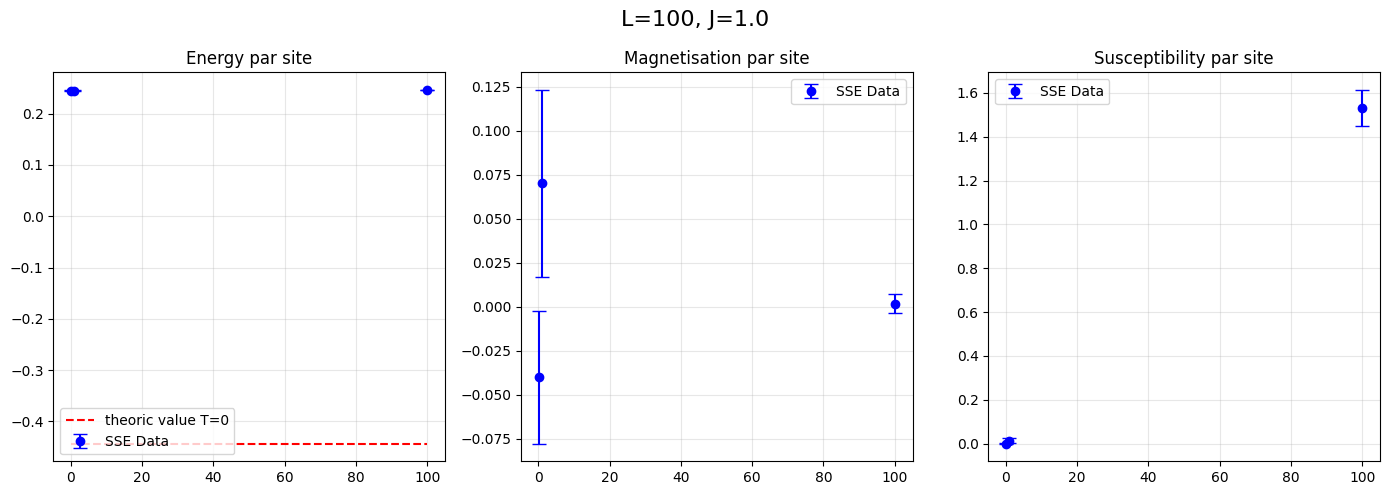

In [210]:
E0 = np.mean(e_list)
E0_theoric = -0.4431

beta_min = min(beta_list)
beta_max = max(beta_list)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

ax1.errorbar(beta_list, e_list, yerr=e_error, fmt='o',
              color='blue', capsize=5, label='SSE Data')
ax1.hlines(E0_theoric, beta_min,  beta_max, linestyle='--', color='red', label='theoric value T=0')
ax1.set_title(f"Energy par site")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.errorbar(beta_list, m_list, yerr=m_error, fmt='o',
              color='blue', capsize=5, label='SSE Data')
#ax2.hlines(m_theoric, beta_min,  beta_max, linestyle='--', color='red', label='theoric value')
ax2.set_title(f"Magnetisation par site")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.errorbar(beta_list, susceptibility_list, yerr=s_error, fmt='o',
              color='blue', capsize=5, label='SSE Data')
#ax3.hlines(susceptibility_theoric, beta_min,  beta_max,, linestyle='--', color='red', label='theoric value')
ax3.set_title(f"Susceptibility par site")
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(f"L={L}, J={J}", fontsize=16)
plt.tight_layout()
plt.show()